# Appendix C - Feature Stress Test (drop Liver Function Score)

This notebook is part of the reproducibility package for the MSc thesis **Probabilistic Machine Learning Models and Decision Optimization for Hepatocellular Carcinoma Diagnosis**.

> Repository note: paths are resolved from either the repository root or the `notebooks/` directory. Generated figures are written under `outputs/`.


# Liver cancer prediction — Model comparison with probability calibration

# Stress Test with dropping Liver Function Score feature

In [1]:
from pathlib import Path
# Import libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.base import clone

from xgboost import XGBClassifier
# Resolve repository root for reproducible relative paths
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent


In [2]:
# Basic playability/display settings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.precision", 4)

In [3]:
# Stress-test setting
SCENARIO = "drop_LFS"
DROP_COLS = ["liver_function_score"]

In [4]:
# File for Tables & Figures
out_dir = REPO_ROOT / "outputs" / "stress_tests"
os.makedirs(out_dir, exist_ok=True)

In [5]:
# Load the dataset.
# TARGET: the name of the target column (binary collation: 0/1).
# Check column types and class proportions, so we know
# if the problem is unbalanced and what preprocessing is needed.
TARGET = "liver_cancer"
df = pd.read_csv(REPO_ROOT / "data" / "synthetic_liver_cancer_dataset.csv")

In [6]:
# Separation into X (features) and y (target)
y = df[TARGET].astype(int).values
X = df.drop(columns=[TARGET] + DROP_COLS)

In [7]:
# Identifying feature types
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [8]:
# Quick summary
display(pd.DataFrame({
    "numeric_cols_count": [len(num_cols)],
    "categorical_cols_count": [len(cat_cols)],
    "class_0_ratio": [(y == 0).mean()],
    "class_1_ratio": [(y == 1).mean()],
}))

,numeric_cols_count,categorical_cols_count,class_0_ratio,class_1_ratio
0,8,4,0.7822,0.2178


In [9]:
# Train / Validation / Test split (60/20/20)
# - TEST is a final hold-out set (never used for model selection).
# - VALIDATION is used for calibration method selection (Brier).
# - TRAIN is used for CV tuning and model selection (ROC-AUC).
# We create a ColumnTransformer:
# - Numerical: missing values (median) + normalization (StandardScaler).
# - Categorical: filling (most_frequent) + One-Hot Encoding.
# We put them in a Pipeline so that the "fit" is done ONLY on the train
# folds (avoid leakage).

In [10]:
# Step 1: create TEST (20%)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

In [11]:
# Step 2: split DEV into TRAIN (60% total) and VAL (20% total)
# 0.25 of 0.80 = 0.20 of total
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=RANDOM_STATE
)

In [12]:
print("TRAIN size:", X_train.shape, "VAL size:", X_val.shape, "TEST size:", X_test.shape)

TRAIN size: (3000, 12) VAL size: (1000, 12) TEST size: (1000, 12)


In [13]:
# Preprocessing

In [14]:
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
preprocessor = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])

In [17]:
# We define three models:
# - Logistic Regression: with class_weight='balanced' for unbalanced data.
# - Random Forest: typical robust baseline.
# - XGBoost: robust gradient boosting model. We define scale_pos_weight =
#   (#negatives / #positives).
# We also create the hyper-parameter grids for GridSearchCV.

In [18]:
log_reg = LogisticRegression(
    max_iter=5000, 
    class_weight="balanced", 
    solver="lbfgs"
)

In [19]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

In [20]:
# scale_pos_weight must be computed ONLY from TRAIN (avoid leakage)
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

In [21]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    n_jobs=-1,
    scale_pos_weight=pos_weight
)

In [22]:
# Pipelines (preprocessing + model)
pipe_lr = Pipeline([
    ("prep", preprocessor), 
    ("clf", log_reg)
])

In [23]:
pipe_rf = Pipeline([
    ("prep", preprocessor), 
    ("clf", rf)
])

In [24]:
pipe_xgb = Pipeline([
    ("prep", preprocessor), 
    ("clf", xgb)
])

In [25]:
# Simple but essential grids for tuning
param_grid_lr = {
    "clf__C": [0.1, 1.0, 3.0],
    "clf__solver": ["lbfgs", "liblinear"]
}

In [26]:
param_grid_rf = {
    "clf__n_estimators": [300, 600],
    "clf__max_depth": [None, 8],
}

In [27]:
param_grid_xgb = {
    "clf__n_estimators": [300, 600],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.03, 0.07],
}

In [28]:
# 5-fold cross-validation for fair assessment of training performance
cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
    random_state=RANDOM_STATE
)

In [29]:
# We run GridSearchCV with ROC-AUC as the main metric for each model.
# GridSearch does internal cross-validation on the train data.
# We keep the best estimator (best_estimator_) for each model.

In [30]:
def tune(pipe, grid, name):
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    # Fit ONLY on X_train/y_train (TRAIN), not on VAL/TEST
    gs.fit(X_train, y_train)
    return {"model": name, "cv_best_roc_auc": gs.best_score_, "best_params": gs.best_params_}, gs.best_estimator_

In [31]:
res_lr, best_lr = tune(pipe_lr, param_grid_lr, "LogisticRegression")

In [32]:
res_rf, best_rf = tune(pipe_rf, param_grid_rf, "RandomForest")

In [33]:
res_xgb, best_xgb = tune(pipe_xgb, param_grid_xgb, "XGBoost")

In [34]:
# Table with tuning results (CV)
tuning_tbl = pd.DataFrame([res_lr, res_rf, res_xgb])
display(tuning_tbl)

,model,cv_best_roc_auc,best_params
0,LogisticRegression,0.9496,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
1,RandomForest,0.9637,"{'clf__max_depth': 8, 'clf__n_estimators': 600}"
2,XGBoost,0.9726,"{'clf__learning_rate': 0.03, 'clf__max_depth':..."


In [35]:
# Sanity checks for near-perfect performance (XGBoost)
# simple checks, NOT used for model selection
# 1) Label permutation test (TRAIN only, CV ROC-AUC should collapse to ~0.5)
# We keep the tuned hyperparameters fixed (best_xgb) and evaluate with the same CV object.
# Baseline CV AUC (tuned XGB, true labels)

In [36]:
xgb_cv_aucs = []
for tr_idx, te_idx in cv.split(X_train, y_train):
    m = clone(best_xgb)
    m.fit(X_train.iloc[tr_idx], y_train[tr_idx])
    proba = m.predict_proba(X_train.iloc[te_idx])[:, 1]
    xgb_cv_aucs.append(roc_auc_score(y_train[te_idx], proba))

print("XGB baseline CV AUC (mean±std):", float(np.mean(xgb_cv_aucs)), float(np.std(xgb_cv_aucs)))

XGB baseline CV AUC (mean±std): 0.9728000162177011 0.002918963279438053


In [37]:
# Permuted-label CV AUC distribution (mean AUC over folds per permutation)

In [38]:
rng = np.random.RandomState(RANDOM_STATE)
perm_cv_auc_means = []
N_PERM = 30

for _ in range(N_PERM):
    y_perm = rng.permutation(y_train)
    fold_aucs = []
    for tr_idx, te_idx in cv.split(X_train, y_perm):
        m = clone(best_xgb)
        m.fit(X_train.iloc[tr_idx], y_perm[tr_idx])
        proba = m.predict_proba(X_train.iloc[te_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y_perm[te_idx], proba))
    perm_cv_auc_means.append(float(np.mean(fold_aucs)))

print("XGB label-permutation CV AUC (mean±std):", float(np.mean(perm_cv_auc_means)), float(np.std(perm_cv_auc_means)))
display(pd.DataFrame({"perm_cv_auc_mean": perm_cv_auc_means}))

XGB label-permutation CV AUC (mean±std): 0.5006195947995272 0.014871469657643178


,perm_cv_auc_mean
0,0.5039
1,0.5130
2,0.5003
3,0.4921
4,0.4896
5,0.5081
6,0.5016
7,0.4856
8,0.5143
9,0.4950


In [39]:
# 2) Repeated stratified splits inside DEV (exclude TEST), fixed tuned XGB
# We repeatedly split DEV into train/hold-out and check whether AUC stays consistently high.

In [40]:
rep_split_aucs = []
N_SPLITS = 20

for seed in range(N_SPLITS):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_dev, y_dev, test_size=0.20, stratify=y_dev, random_state=seed
    )
    m = clone(best_xgb)
    m.fit(X_tr_s, y_tr_s)
    proba = m.predict_proba(X_te_s)[:, 1]
    rep_split_aucs.append(float(roc_auc_score(y_te_s, proba)))

rep_split_aucs = np.array(rep_split_aucs)

In [41]:
print("XGB repeated DEV splits AUC (mean±std):", float(rep_split_aucs.mean()), float(rep_split_aucs.std()))
print("XGB repeated DEV splits AUC (min/max):", float(rep_split_aucs.min()), float(rep_split_aucs.max()))
display(pd.DataFrame({"repeat_split_auc": rep_split_aucs}))

XGB repeated DEV splits AUC (mean±std): 0.9747801219198706 0.003744700499727403
XGB repeated DEV splits AUC (min/max): 0.9652647717674708 0.980178840292314


,repeat_split_auc
0,0.9781
1,0.9765
2,0.9653
3,0.9709
4,0.9788
5,0.9787
6,0.9717
7,0.9751
8,0.9724
9,0.9766


In [42]:
# We use an explicit StratifiedKFold object also for the calibration step
# (instead of passing cv=5). This keeps the procedure stratified and reproducible.
cv_cal = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
    random_state=RANDOM_STATE
)

In [43]:
# To make the probabilities "fair", we calibrate the models with CalibratedClassifierCV.
# We test two methods: 'isotonic' and 'sigmoid' (Platt scaling).
# Selection is made based on the Brier score on a validation set.
# - We now pass an explicit StratifiedKFold (cv_cal) to the calibrator.
#   This makes calibration:
#   (a) stratified
#   (b) reproducible (shuffle + random_state)

In [44]:
def pick_calibration(model, X_tr, y_tr, X_val, y_val, cv_cal):
    methods = {}
    scores = {}
    for m in ["isotonic", "sigmoid"]:
        cal = CalibratedClassifierCV(model, method=m, cv=cv_cal)
        cal.fit(X_tr, y_tr)
        proba_val = cal.predict_proba(X_val)[:, 1]
        scores[m] = brier_score_loss(y_val, proba_val)
        methods[m] = cal
    best_m = min(scores, key=scores.get)  # smaller Brier = better calibration
    return methods[best_m], best_m, scores

In [45]:
# Calibration method selection is based directly on the VAL set.

In [46]:
cal_lr,  m_lr,  s_lr  = pick_calibration(best_lr,  X_train, y_train, X_val, y_val, cv_cal)

In [47]:
cal_rf,  m_rf,  s_rf  = pick_calibration(best_rf,  X_train, y_train, X_val, y_val, cv_cal)

In [48]:
cal_xgb, m_xgb, s_xgb = pick_calibration(best_xgb, X_train, y_train, X_val, y_val, cv_cal)

In [49]:
# Table: which method was chosen and what Brier gave in validation
calibration_tbl = pd.DataFrame([
    {"model": "LogisticRegression", "picked": m_lr, "val_brier": s_lr[m_lr]},
    {"model": "RandomForest", "picked": m_rf, "val_brier": s_rf[m_rf]},
    {"model": "XGBoost", "picked": m_xgb, "val_brier": s_xgb[m_xgb]},
])

# Display the calibration-method selection and its quality on the VALIDATION set
# (lower Brier = better probability calibration)
display(calibration_tbl)

,model,picked,val_brier
0,LogisticRegression,sigmoid,0.0672
1,RandomForest,isotonic,0.0463
2,XGBoost,isotonic,0.0307


In [50]:
# Final fit of the “winners” over ALL development data (TRAIN + VAL)
# After selecting the calibration option on VALIDATION,
# we refit each calibrated model on the full development set (TRAIN + VAL)
# to maximize training signal, while keeping TEST untouched.

In [51]:
X_dev_final = pd.concat([X_train, X_val], axis=0)
y_dev_final = np.concatenate([y_train, y_val], axis=0)

In [52]:
cal_lr.fit(X_dev_final, y_dev_final)

,estimator,Pipeline(step..._iter=5000))])
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [53]:
cal_rf.fit(X_dev_final, y_dev_final)

,estimator,Pipeline(step...m_state=42))])
,method,'isotonic'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [54]:
cal_xgb.fit(X_dev_final, y_dev_final)

,estimator,"Pipeline(step...=None, ...))])"
,method,'isotonic'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [55]:
# Here we define:
# - bootstrap_ci: calculates confidence intervals (percentile) for a metric (e.g. AUC or AP)
# - evaluate: returns AUC, AP (PR-AUC), Brier in the test set and the vector with probabilities

In [56]:
def bootstrap_ci(y_true, proba, metric_fn, n_boot=2000, alpha=0.05, rng=RANDOM_STATE):
    rng = np.random.RandomState(rng)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)  # bootstrap sample with resampling
        stats.append(metric_fn(y_true[idx], proba[idx]))
    lo, hi = np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(np.mean(stats)), (float(lo), float(hi))

In [57]:
def evaluate(model, name):
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    brier = brier_score_loss(y_test, proba)
    # 95% CI with bootstrap for AUC and AP
    _, auc_ci = bootstrap_ci(y_test, proba, roc_auc_score)
    _, ap_ci = bootstrap_ci(y_test, proba, average_precision_score)
    return {"model": name, "auc": auc, "auc_ci": auc_ci, "ap": ap, "ap_ci": ap_ci, "brier": brier}, proba

In [58]:
# TEST evaluation (strictly for reporting and not for selection)
m_lr, p_lr = evaluate(cal_lr, "LR")

In [59]:
m_rf, p_rf = evaluate(cal_rf, "RF")

In [60]:
m_xgb, p_xgb = evaluate(cal_xgb, "XGB")

In [61]:
# Summary table for the test set
summary = pd.DataFrame([m_lr, m_rf, m_xgb])[["model", "auc", "auc_ci", "ap", "ap_ci", "brier"]]
summary = summary.sort_values("auc", ascending=False)
display(summary)

,model,auc,auc_ci,ap,ap_ci,brier
2,XGB,0.9743,"(0.9647309793355102, 0.9829480558896277)",0.9380,"(0.9152650549499639, 0.9581701054407)",0.0374
1,RF,0.9677,"(0.9574512027937174, 0.977500531620993)",0.9209,"(0.89515685727975, 0.9442236016136035)",0.0510
0,LR,0.9514,"(0.9377558840646791, 0.9644298334099106)",0.8680,"(0.8295846080145411, 0.9036508677033478)",0.0687


In [62]:
# Here we produce 3 single charts (one for each metric).
# Each model has a different color.
colors = {"LR": "C0", "RF": "C1", "XGB": "C2"}

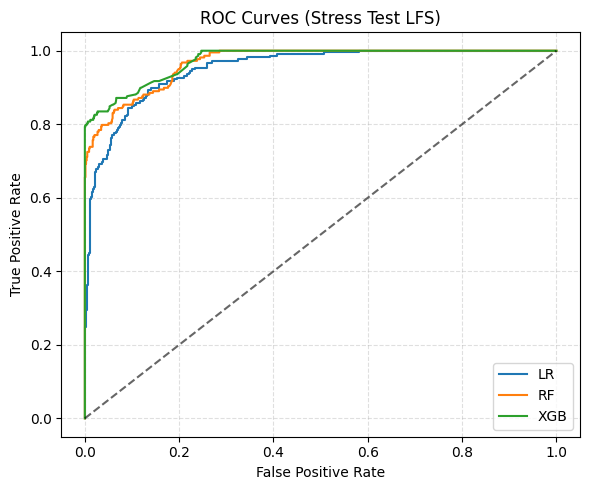

In [63]:
# 1) ROC (a chart with all the curves)
plt.figure(figsize=(6, 5))
for name, proba in [("LR", p_lr), ("RF", p_rf), ("XGB", p_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name, color=colors[name])

plt.plot([0, 1], [0, 1], "--", color="black", alpha=0.6)  # random classifier
plt.title("ROC Curves (Stress Test LFS)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{out_dir}/roc_curve_stress_test_LFS.png", dpi=300, bbox_inches="tight")
plt.show()

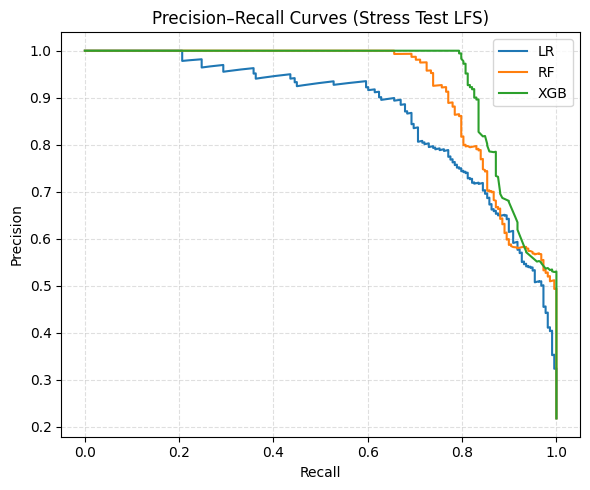

In [64]:
# 2) Precision–Recall (a diagram with all the curves)
plt.figure(figsize=(6, 5))
for name, proba in [("LR", p_lr), ("RF", p_rf), ("XGB", p_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name, color=colors[name])

plt.title("Precision–Recall Curves (Stress Test LFS)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{out_dir}/precision_recall_curve_stress_test_LFS.png", dpi=300, bbox_inches="tight")
plt.show()

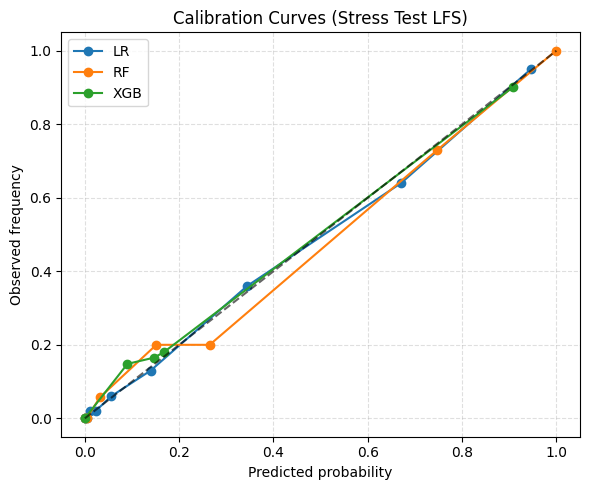

In [65]:
# 3) Calibration (a diagram with all the curves)
plt.figure(figsize=(6, 5))
for name, proba in [("LR", p_lr), ("RF", p_rf), ("XGB", p_xgb)]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=name, color=colors[name])

plt.plot([0, 1], [0, 1], "--", color="black", alpha=0.6)  # perfect calibration
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curves (Stress Test LFS)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{out_dir}/calibration_curve_stress_test_LFS.png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
# Model Selection
# We use two criteria, each evaluated on the appropriate split:
#   1) Discrimination  -> CV ROC-AUC on TRAIN (from GridSearchCV)
#      ROC-AUC tells us how well the model ranks positives above negatives.
#   2) Probability quality -> Brier score on VALIDATION (after calibration)
#      Brier tells us how good the predicted probabilities are (calibration + sharpness).
# - The TEST set is NOT used at all for selecting the model.
# - TEST is used ONLY once, for the final unbiased report.

In [67]:
# Join the tuning (CV) results with the validation calibration quality (Brier)
model_selection_tbl = tuning_tbl.merge(
    calibration_tbl[["model", "val_brier"]],
    on="model",
    how="left"
)
display(model_selection_tbl)

,model,cv_best_roc_auc,best_params,val_brier
0,LogisticRegression,0.9496,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}",0.0672
1,RandomForest,0.9637,"{'clf__max_depth': 8, 'clf__n_estimators': 600}",0.0463
2,XGBoost,0.9726,"{'clf__learning_rate': 0.03, 'clf__max_depth':...",0.0307


In [68]:
# Selection rule:
# - Primary objective: maximize CV ROC-AUC (discrimination).
# - Secondary objective: minimize VAL Brier (probability quality).
# This is a simple deterministic multi-objective selection:
# sort by AUC (descending) and then by Brier (ascending).

In [69]:
winner_row = model_selection_tbl.sort_values(
    ["cv_best_roc_auc", "val_brier"],
    ascending=[False, True]
).iloc[0]

winner_cv = winner_row["model"]
print("Best model (TRAIN CV ROC-AUC + VAL Brier tie-break):", winner_cv)

Best model (TRAIN CV ROC-AUC + VAL Brier tie-break): XGBoost
